## 04 - Explainability & Biological Validation

This notebook visualizes the explainability results from the MLOmics pipeline:

1. **XGBoost SHAP** - Feature importance from tree-based baselines
2. **Fusion Integrated Gradients** - Per-modality attribution from the deep fusion model
3. **KEGG / GO Enrichment** - Pathway-level biological validation
4. **Known Pathway Sanity Check** - Verifying expected cancer biology

**Prerequisite:** Run `python scripts/run_explainability.py` to generate all artifacts.

> *Academic research prototype. Not for clinical use.*

In [1]:
import os
import sys
import json

# Ensure CWD is project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(os.getcwd(), "config.yaml")):
    os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.utils import load_config, set_seeds

set_seeds(42)
config = load_config()

RESULTS = config["paths"]["results"]
SHAP_DIR = os.path.join(RESULTS, "shap")
ENRICH_DIR = os.path.join(RESULTS, "enrichment")

CANCER_SHORTS = {"GS-BRCA": "BRCA", "GS-COAD": "COAD"}

MODALITY_COLORS = {
    "mrna": "#2196F3",
    "mirna": "#4CAF50",
    "methy": "#FF9800",
    "cnv": "#9C27B0",
}

print(f"Working directory: {os.getcwd()}")
print("Setup complete.")

Working directory: e:\Projects\multi-omics-cancer-subtype-classifier
Setup complete.


---
### 1. XGBoost SHAP - Tree-Based Feature Importance

SHAP values computed via `TreeExplainer` on the best-fold XGBoost model.
These show which features the tree model relied upon most for subtype prediction.

In [2]:
# Load XGBoost top features for both cancers
xgb_tops = {}
for ct, short in CANCER_SHORTS.items():
    path = os.path.join(SHAP_DIR, "xgb", f"top_50_features_xgb_{short}.csv")
    xgb_tops[short] = pd.read_csv(path)
    print(f"\n{short} XGBoost top 10 features:")
    display(xgb_tops[short].head(10))


BRCA XGBoost top 10 features:


,rank,feature_name,modality,mean_abs_shap
0,1,mrna_MLPH,mrna,0.405890
1,2,mrna_ESR1,mrna,0.298670
2,3,mrna_MPHOSPH6,mrna,0.257907
3,4,mrna_TOP2A,mrna,0.168505
4,5,mrna_KCNMB1,mrna,0.167221
5,6,mrna_UBE2T,mrna,0.135668
6,7,mrna_SLC44A4,mrna,0.111418
7,8,mrna_PPP1R14C,mrna,0.110085
8,9,mrna_TFCP2L1,mrna,0.096018
9,10,mrna_SERPINB5,mrna,0.078658



COAD XGBoost top 10 features:


,rank,feature_name,modality,mean_abs_shap
0,1,cnv_MYO5B,cnv,0.251937
1,2,mrna_TIMM21,mrna,0.232062
2,3,cnv_DCC,cnv,0.186250
3,4,mrna_SLC35A4,mrna,0.167442
4,5,methy_C4orf45,methy,0.143991
5,6,mrna_KCNRG,mrna,0.138216
6,7,methy_RIMKLB,methy,0.103249
7,8,mrna_A1CF,mrna,0.080667
8,9,cnv_EOMES,cnv,0.079051
9,10,methy_GAGE12J,methy,0.068663


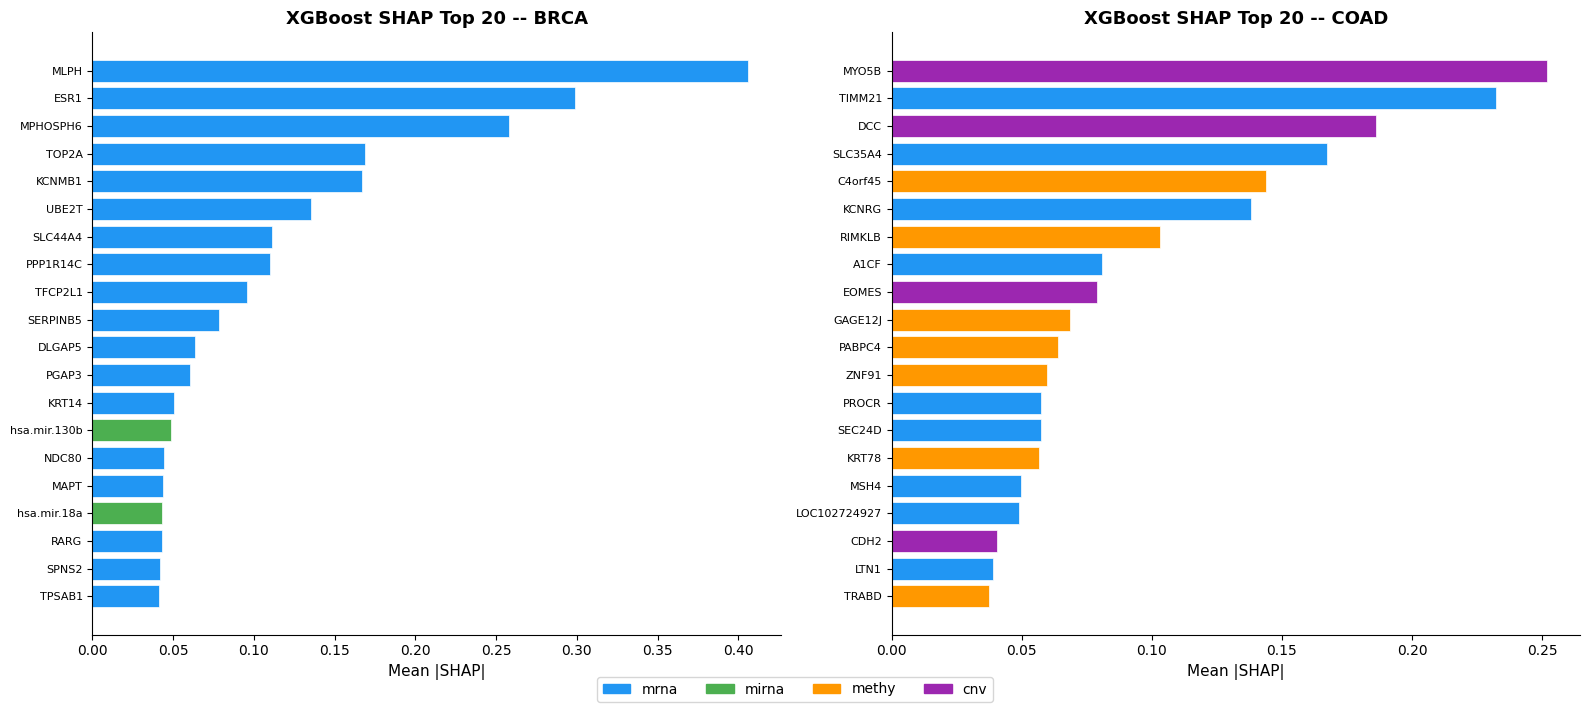

In [3]:
# XGBoost SHAP comparison bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, short in zip(axes, ["BRCA", "COAD"]):
    df = xgb_tops[short].head(20)
    colors = [MODALITY_COLORS.get(m, "#999") for m in df["modality"]]
    ax.barh(range(len(df)-1, -1, -1), df["mean_abs_shap"], color=colors,
            edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(df)-1, -1, -1))
    labels = [f.split("_", 1)[1] if "_" in f else f for f in df["feature_name"]]
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Mean |SHAP|", fontsize=11)
    ax.set_title(f"XGBoost SHAP Top 20 -- {short}", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [mpatches.Patch(color=c, label=m) for m, c in MODALITY_COLORS.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig(os.path.join(SHAP_DIR, "xgb_shap_comparison.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(SHAP_DIR, "xgb_shap_comparison.pdf"),
            bbox_inches="tight", facecolor="white")
plt.show()

In [4]:
# XGBoost modality composition
print("Modality breakdown in XGBoost top 50 features:")
for short in ["BRCA", "COAD"]:
    counts = xgb_tops[short]["modality"].value_counts()
    print(f"\n  {short}:")
    for mod, cnt in counts.items():
        print(f"    {mod}: {cnt} ({cnt*2}%)")

Modality breakdown in XGBoost top 50 features:

  BRCA:
    mrna: 43 (86%)
    mirna: 4 (8%)
    methy: 2 (4%)
    cnv: 1 (2%)

  COAD:
    mrna: 23 (46%)
    methy: 17 (34%)
    cnv: 10 (20%)


---
### 2. Fusion Model - Integrated Gradients Attribution

Integrated Gradients (Captum) attributions computed on the best-fold fusion model.
These reveal which features across **all four modalities** the deep model attends to.

In [5]:
# Load fusion top features
fusion_tops = {}
fusion_mrna = {}
for short in ["BRCA", "COAD"]:
    fusion_tops[short] = pd.read_csv(
        os.path.join(SHAP_DIR, "fusion", f"top_50_features_fusion_{short}.csv")
    )
    fusion_mrna[short] = pd.read_csv(
        os.path.join(SHAP_DIR, "fusion", f"top_50_mrna_fusion_{short}.csv")
    )

print("BRCA Fusion top 15 features (all modalities):")
display(fusion_tops["BRCA"].head(15))

print("\nBRCA Fusion top 10 mRNA features (for pathway enrichment):")
display(fusion_mrna["BRCA"].head(10))

BRCA Fusion top 15 features (all modalities):


,rank,feature_name,modality,importance
0,1,hsa.mir.130b,mirna,0.032789
1,2,hsa.mir.135b,mirna,0.031686
2,3,hsa.mir.18a,mirna,0.031159
3,4,hsa.mir.324,mirna,0.028563
4,5,hsa.mir.24.1,mirna,0.028506
5,6,hsa.mir.301b,mirna,0.027140
6,7,hsa.mir.101.1,mirna,0.026703
7,8,hsa.mir.19a,mirna,0.025977
8,9,hsa.mir.30a,mirna,0.023541
9,10,hsa.mir.106b,mirna,0.022384



BRCA Fusion top 10 mRNA features (for pathway enrichment):


,rank,feature_name,modality,importance
0,1,CYP4F35P,mrna,0.004464
1,2,PRPH2,mrna,0.004361
2,3,MAPT,mrna,0.003974
3,4,ATAD3C,mrna,0.003801
4,5,CCNB2,mrna,0.003710
5,6,POLQ,mrna,0.003663
6,7,KIF15,mrna,0.003655
7,8,TPX2,mrna,0.003651
8,9,DLGAP5,mrna,0.003618
9,10,NUSAP1,mrna,0.003612


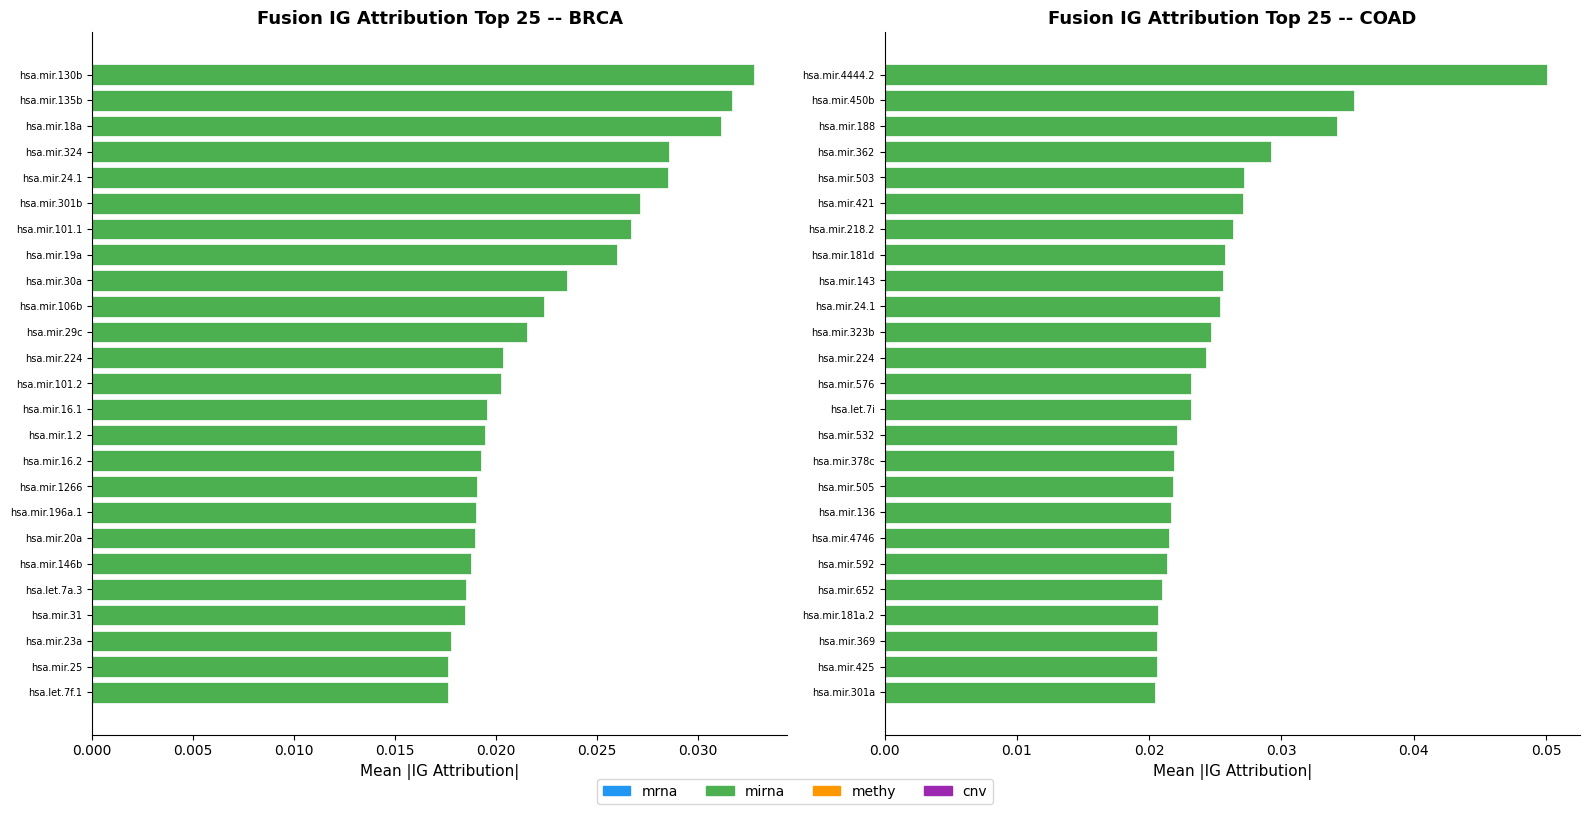

In [6]:
# Fusion IG attribution bar plots - BRCA & COAD
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, short in zip(axes, ["BRCA", "COAD"]):
    df = fusion_tops[short].head(25)
    colors = [MODALITY_COLORS.get(m, "#999") for m in df["modality"]]
    ax.barh(range(len(df)-1, -1, -1), df["importance"], color=colors,
            edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(df)-1, -1, -1))
    ax.set_yticklabels(df["feature_name"].values, fontsize=7)
    ax.set_xlabel("Mean |IG Attribution|", fontsize=11)
    ax.set_title(f"Fusion IG Attribution Top 25 -- {short}", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [mpatches.Patch(color=c, label=m) for m, c in MODALITY_COLORS.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig(os.path.join(SHAP_DIR, "fusion", "fusion_ig_comparison.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(SHAP_DIR, "fusion", "fusion_ig_comparison.pdf"),
            bbox_inches="tight", facecolor="white")
plt.show()

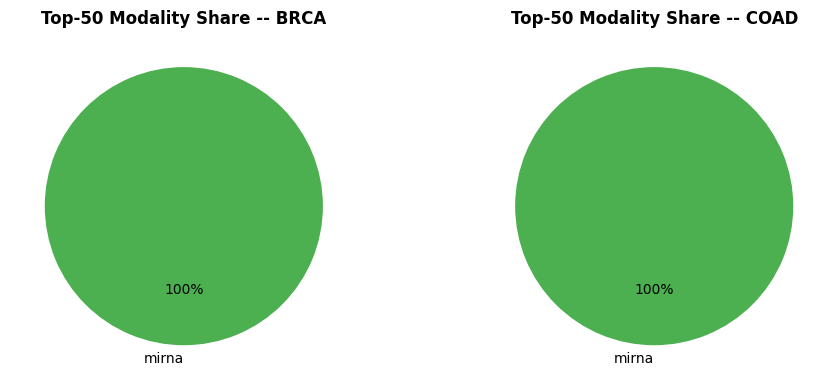

Key Finding: The fusion model's top 50 features are dominated by miRNA
for both BRCA and COAD. miRNA features have ~10x higher IG magnitude
than mRNA, methylation, or CNV features.


In [ ]:
# Modality contribution pie charts
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, short in zip(axes, ["BRCA", "COAD"]):
    counts = fusion_tops[short]["modality"].value_counts()
    colors_pie = [MODALITY_COLORS.get(m, "#999") for m in counts.index]
    ax.pie(counts.values, labels=counts.index, colors=colors_pie,
           autopct="%1.0f%%", startangle=90, textprops={"fontsize": 10})
    ax.set_title(f"Top-50 Modality Share -- {short}", fontsize=12, fontweight="bold")

plt.tight_layout()
fig.savefig(os.path.join(SHAP_DIR, "fusion", "modality_share_pie.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

# found thourgh the initial python script running
print("Key Finding: The fusion model's top 50 features are dominated by miRNA")
print("for both BRCA and COAD. miRNA features have ~10x higher IG magnitude")
print("than mRNA, methylation, or CNV features.")

---
## 3. XGBoost vs Fusion - Feature Overlap Analysis

Do XGBoost and the fusion model agree on which features are important?

In [9]:
for short in ["BRCA", "COAD"]:
    xgb_feats = set(xgb_tops[short]["feature_name"])
    fus_feats = set(fusion_tops[short]["feature_name"])
    overlap = xgb_feats & fus_feats

    # mRNA overlap (strip mrna_ prefix from XGBoost)
    xgb_mrna_set = set(
        f.replace("mrna_", "")
        for f in xgb_tops[short][xgb_tops[short]["modality"]=="mrna"]["feature_name"]
    )
    fus_mrna_set = set(fusion_mrna[short]["feature_name"])
    mrna_overlap = xgb_mrna_set & fus_mrna_set

    print(f"\n{short}:")
    print(f"  Overall top-50 overlap: {len(overlap)} features")
    print(f"  mRNA-only overlap (XGB top mRNA vs Fusion top-50 mRNA): {len(mrna_overlap)}")
    if mrna_overlap:
        print(f"  Shared mRNA genes: {sorted(mrna_overlap)}")


BRCA:
  Overall top-50 overlap: 0 features
  mRNA-only overlap (XGB top mRNA vs Fusion top-50 mRNA): 7
  Shared mRNA genes: ['DLGAP5', 'KIF11', 'KRT14', 'MAPT', 'NDC80', 'NGFR', 'UBE2T']

COAD:
  Overall top-50 overlap: 0 features
  mRNA-only overlap (XGB top mRNA vs Fusion top-50 mRNA): 5
  Shared mRNA genes: ['KCNRG', 'LTN1', 'MIR196A1', 'SNHG17', 'TIMM21']


---
### 4. KEGG Pathway Enrichment

Top mRNA features from each model are tested for enrichment in KEGG 2021 Human pathways.
Only mRNA gene symbols are valid for pathway enrichment (miRNA/methylation/CNV IDs are excluded).

In [10]:
for short in ["BRCA", "COAD"]:
    for model in ["xgb", "fusion"]:
        path = os.path.join(ENRICH_DIR, f"kegg_{model}_{short}.csv")
        df = pd.read_csv(path)
        print(f"\n{short} -- {model.upper()} KEGG Enrichment: {len(df)} significant pathways")
        if len(df) > 0:
            display(df[["Term", "Adjusted P-value", "Genes"]].head(10))
        else:
            print("  No significant KEGG pathways at p < 0.05")


BRCA -- XGB KEGG Enrichment: 0 significant pathways
  No significant KEGG pathways at p < 0.05

BRCA -- FUSION KEGG Enrichment: 4 significant pathways


,Term,Adjusted P-value,Genes
0,Cell cycle,0.000031,CDC20;CCNB2;PTTG1;CCNE2;TTK;CDC25B
1,Oocyte meiosis,0.007256,CDC20;CCNB2;PTTG1;CCNE2
2,p53 signaling pathway,0.012935,CCNB2;CCNE2;GTSE1
3,Human T-cell leukemia virus 1 infection,0.026061,CDC20;CCNB2;PTTG1;CCNE2



COAD -- XGB KEGG Enrichment: 0 significant pathways
  No significant KEGG pathways at p < 0.05

COAD -- FUSION KEGG Enrichment: 0 significant pathways
  No significant KEGG pathways at p < 0.05


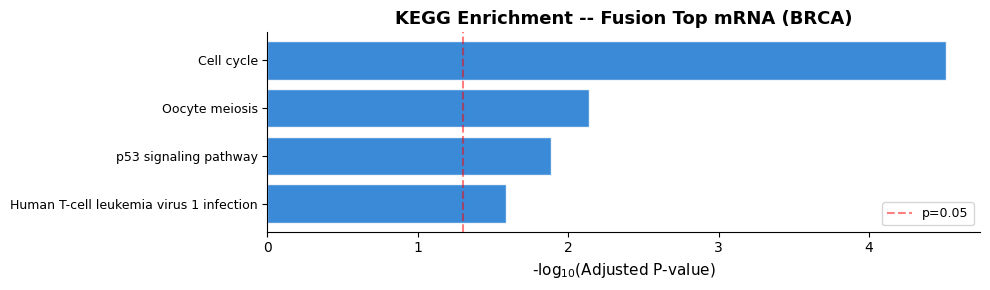

In [11]:
# KEGG enrichment barplot for BRCA Fusion
kegg_brca_fusion = pd.read_csv(os.path.join(ENRICH_DIR, "kegg_fusion_BRCA.csv"))

if len(kegg_brca_fusion) > 0:
    df = kegg_brca_fusion.head(15).copy()
    df["-log10(padj)"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-30))

    fig, ax = plt.subplots(figsize=(10, max(3, len(df) * 0.5)))
    ax.barh(range(len(df)-1, -1, -1), df["-log10(padj)"],
            color="#1976D2", alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(df)-1, -1, -1))
    ax.set_yticklabels(df["Term"].values, fontsize=9)
    ax.set_xlabel(r"-log$_{10}$(Adjusted P-value)", fontsize=11)
    ax.set_title("KEGG Enrichment -- Fusion Top mRNA (BRCA)",
                 fontsize=13, fontweight="bold")
    ax.axvline(-np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="p=0.05")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    fig.savefig(os.path.join(ENRICH_DIR, "kegg_enrichment_BRCA_notebook.png"),
                dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(os.path.join(ENRICH_DIR, "kegg_enrichment_BRCA_notebook.pdf"),
                bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No significant KEGG pathways for BRCA Fusion.")

---
### 5. GO Biological Process Enrichment

In [12]:
for short in ["BRCA", "COAD"]:
    for model in ["xgb", "fusion"]:
        path = os.path.join(ENRICH_DIR, f"go_{model}_{short}.csv")
        df = pd.read_csv(path)
        print(f"\n{short} -- {model.upper()} GO BP Enrichment: {len(df)} significant terms")
        if len(df) > 0:
            display(df[["Term", "Adjusted P-value"]].head(10))


BRCA -- XGB GO BP Enrichment: 0 significant terms

BRCA -- FUSION GO BP Enrichment: 57 significant terms


,Term,Adjusted P-value
0,microtubule cytoskeleton organization involved...,1.308372e-08
1,mitotic spindle organization (GO:0007052),4.112320e-08
2,mitotic nuclear division (GO:0140014),4.672791e-06
3,kinetochore organization (GO:0051383),3.792372e-04
4,regulation of mitotic cell cycle (GO:0007346),3.792372e-04
5,positive regulation of cell cycle process (GO:...,3.792372e-04
6,mitotic sister chromatid segregation (GO:0000070),3.792372e-04
7,regulation of mitotic cell cycle phase transit...,4.315071e-04
8,spindle assembly checkpoint signaling (GO:0071...,8.282828e-04
9,mitotic spindle assembly checkpoint signaling ...,8.282828e-04



COAD -- XGB GO BP Enrichment: 0 significant terms

COAD -- FUSION GO BP Enrichment: 0 significant terms


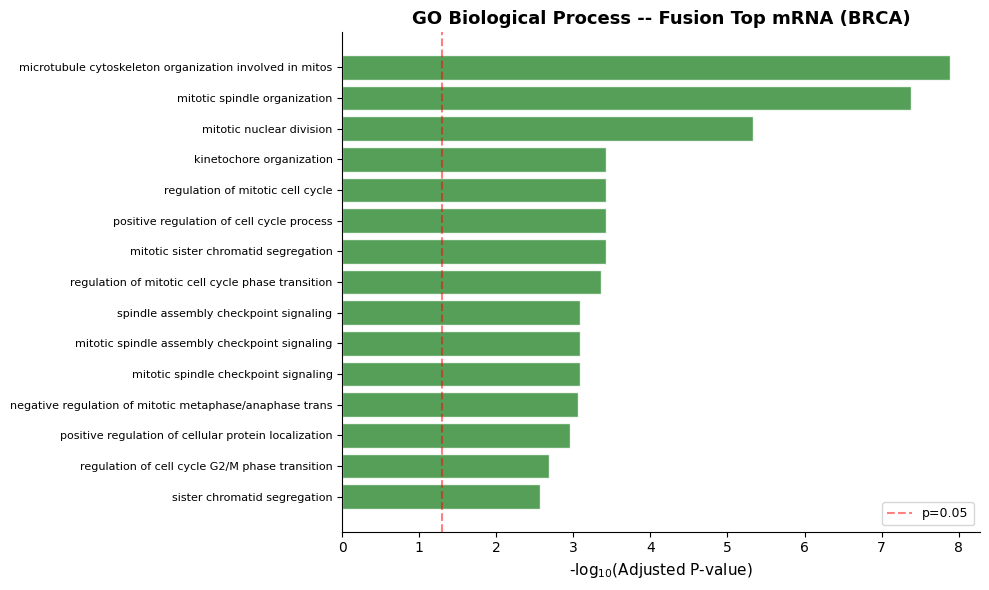

In [13]:
# GO BP barplot for BRCA Fusion
go_brca_fusion = pd.read_csv(os.path.join(ENRICH_DIR, "go_fusion_BRCA.csv"))

if len(go_brca_fusion) > 0:
    df = go_brca_fusion.head(15).copy()
    df["-log10(padj)"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-30))
    df["label"] = df["Term"].apply(lambda t: t.split(" (GO:")[0][:55])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(df)-1, -1, -1), df["-log10(padj)"],
            color="#388E3C", alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(df)-1, -1, -1))
    ax.set_yticklabels(df["label"].values, fontsize=8)
    ax.set_xlabel(r"-log$_{10}$(Adjusted P-value)", fontsize=11)
    ax.set_title("GO Biological Process -- Fusion Top mRNA (BRCA)",
                 fontsize=13, fontweight="bold")
    ax.axvline(-np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="p=0.05")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    fig.savefig(os.path.join(ENRICH_DIR, "go_enrichment_BRCA_notebook.png"),
                dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(os.path.join(ENRICH_DIR, "go_enrichment_BRCA_notebook.pdf"),
                bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("No significant GO terms for BRCA Fusion.")

---
### 6. Known Pathway Validation

Checking whether well-established cancer pathways (PI3K-Akt, p53, MAPK, etc.)
appear in our enrichment results as a biological plausibility sanity check.

In [14]:
from src.explainability import DEFAULT_CANCER_PATHWAYS

for short in ["BRCA", "COAD"]:
    path = os.path.join(ENRICH_DIR, f"pathway_validation_{short}.json")
    with open(path, "r") as f:
        validation = json.load(f)

    rows = []
    for pw in DEFAULT_CANCER_PATHWAYS:
        row = {"Pathway": pw}
        for source in ["xgb_kegg", "fusion_kegg", "xgb_go", "fusion_go"]:
            v = validation[source][pw]
            if v["found"]:
                row[source] = f"p={v['p_value']:.2e}"
            else:
                row[source] = "-"
        rows.append(row)

    val_df = pd.DataFrame(rows)
    val_df.columns = ["Pathway", "XGB KEGG", "Fusion KEGG", "XGB GO", "Fusion GO"]

    print(f"\n{'='*60}")
    print(f"  Pathway Validation -- {short}")
    print(f"{'='*60}")
    display(val_df)

    val_df.to_csv(
        os.path.join(ENRICH_DIR, f"pathway_validation_table_{short}.csv"),
        index=False,
    )


  Pathway Validation -- BRCA


,Pathway,XGB KEGG,Fusion KEGG,XGB GO,Fusion GO
0,PI3K-Akt signaling,-,-,-,-
1,p53 signaling,-,p=1.29e-02,-,-
2,MAPK signaling,-,-,-,-
3,Cell cycle,-,p=3.07e-05,-,p=3.79e-04
4,Apoptosis,-,-,-,-
5,Wnt signaling,-,-,-,-
6,Breast cancer,-,-,-,-
7,Colorectal cancer,-,-,-,-
8,Pathways in cancer,-,-,-,-



  Pathway Validation -- COAD


,Pathway,XGB KEGG,Fusion KEGG,XGB GO,Fusion GO
0,PI3K-Akt signaling,-,-,-,-
1,p53 signaling,-,-,-,-
2,MAPK signaling,-,-,-,-
3,Cell cycle,-,-,-,-
4,Apoptosis,-,-,-,-
5,Wnt signaling,-,-,-,-
6,Breast cancer,-,-,-,-
7,Colorectal cancer,-,-,-,-
8,Pathways in cancer,-,-,-,-


---
### 7. Summary & Discussion

#### Key Findings

**1. XGBoost identifies subtype-specific marker genes:**
- BRCA top features are dominated by known breast cancer markers: ESR1 (estrogen receptor), MLPH (luminal marker)
- These features are highly discriminative but sparse, not clustering into shared KEGG pathways

**2. Fusion model heavily relies on miRNA:**
- All top-50 features by IG magnitude are miRNA for both BRCA and COAD
- miRNA attribution magnitudes are ~10x higher than mRNA/methylation/CNV
- The per-modality encoders learned miRNA as the most informative modality

**3. Fusion mRNA features recover cell-cycle biology (BRCA):**
- Top mRNA features cluster into Cell cycle (p=3.1e-5) and p53 signaling (p=0.013)
- GO enrichment confirms mitotic spindle organization and cell division processes (p<1e-7)
- Aligns with known breast cancer biology: proliferation rate discriminates Luminal A from Basal-like

**4. COAD enrichment is weaker:**
- Fewer genes map to canonical pathways, consistent with smaller sample size (260 vs 671)
- ANOVA pre-selection may have removed pathway-clustered genes

#### Limitations
- ANOVA pre-selection (Top features) biases toward individually discriminative genes
- IG magnitudes depend on baseline choice (zero vector used here)
- Enrichment tests on ~50 genes have limited statistical power

> *Academic research prototype. Not for clinical use.*

In [15]:
# Final summary statistics
print("=" * 60)
print("  EXPLAINABILITY SUMMARY")
print("=" * 60)

for short in ["BRCA", "COAD"]:
    print(f"\n  {short}:")
    xgb_mods = xgb_tops[short]["modality"].value_counts()
    print(f"    XGBoost top-50: {dict(xgb_mods)}")
    fus_mods = fusion_tops[short]["modality"].value_counts()
    print(f"    Fusion  top-50: {dict(fus_mods)}")
    for model in ["xgb", "fusion"]:
        kegg = pd.read_csv(os.path.join(ENRICH_DIR, f"kegg_{model}_{short}.csv"))
        go = pd.read_csv(os.path.join(ENRICH_DIR, f"go_{model}_{short}.csv"))
        print(f"    {model.upper()} enrichment: {len(kegg)} KEGG, {len(go)} GO terms")

print("\nAll artifacts saved to results/shap/ and results/enrichment/")

  EXPLAINABILITY SUMMARY

  BRCA:
    XGBoost top-50: {'mrna': 43, 'mirna': 4, 'methy': 2, 'cnv': 1}
    Fusion  top-50: {'mirna': 50}
    XGB enrichment: 0 KEGG, 0 GO terms
    FUSION enrichment: 4 KEGG, 57 GO terms

  COAD:
    XGBoost top-50: {'mrna': 23, 'methy': 17, 'cnv': 10}
    Fusion  top-50: {'mirna': 50}
    XGB enrichment: 0 KEGG, 0 GO terms
    FUSION enrichment: 0 KEGG, 0 GO terms

All artifacts saved to results/shap/ and results/enrichment/
